In [1]:
%cd ..
from app.conf.run import build_interpretability_run_config
from app.modeling import build_model
from app.data_providers import ready_split_dataset
from plot.interpretability import feature_importance_bar_plot, ShapPlotter, create_shap_plotter_from_model_and_data
from evaluation.shap import shap_explainer, shap_values
%cd notebooks

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions


I0000 00:00:1779795044.926946  562878 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779795044.927443  562878 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779795044.967971  562878 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779795046.043148  562878 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks


In [2]:
config = build_interpretability_run_config()
model = build_model(config.model_config)
%cd ..
X_train, y_train, X_test, y_test, X_train_orig, X_test_orig = ready_split_dataset(config)
%cd notebooks
model.fit(X_train,y_train)
shap_plotter = create_shap_plotter_from_model_and_data(model, X_test, X_train)

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions


Repo card metadata block was not found. Setting CardData to empty.


/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks
[LightGBM] [Info] Number of positive: 147686, number of negative: 157976
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003989 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 945
[LightGBM] [Info] Number of data points in the train set: 305662, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483168 -> initscore=-0.067355
[LightGBM] [Info] Start training from score -0.067355


/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


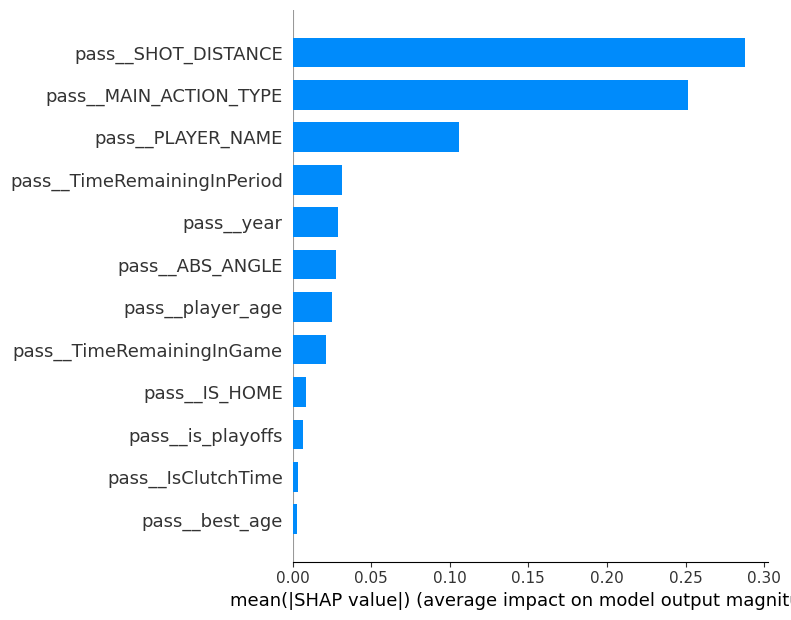

In [3]:
shap_plotter.plot_summary()

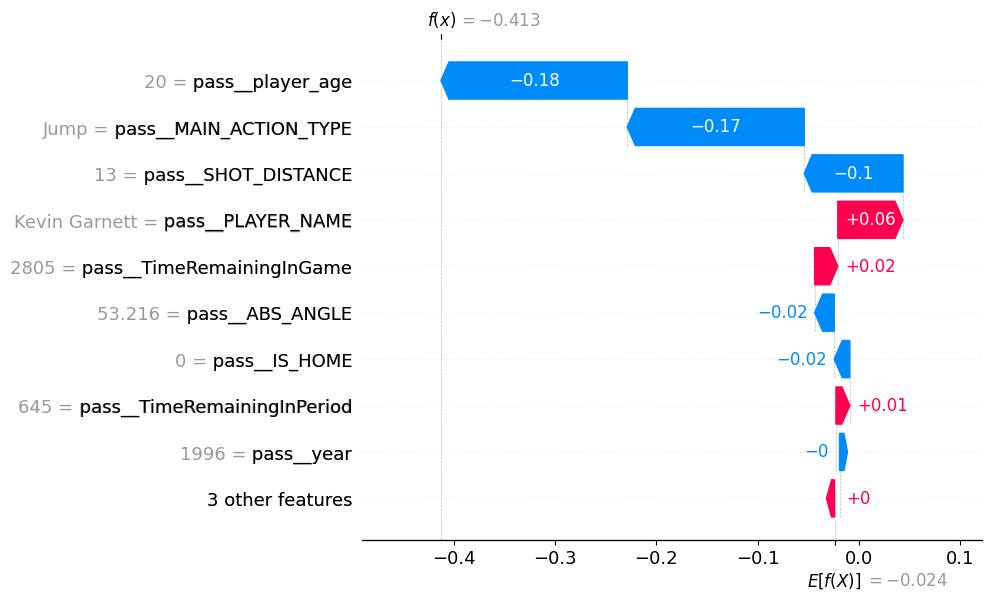

In [4]:
import matplotlib.pyplot as plt
shap_plotter.plot_waterfall(3)
plt.show()

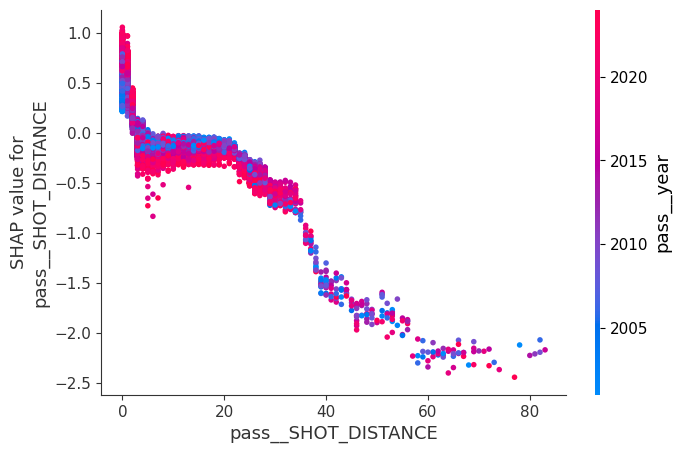

In [6]:
import shap
shap.dependence_plot(
            "pass__SHOT_DISTANCE",
            shap_plotter.shap_values,
            X_test
        )

<Figure size 3500x3500 with 0 Axes>

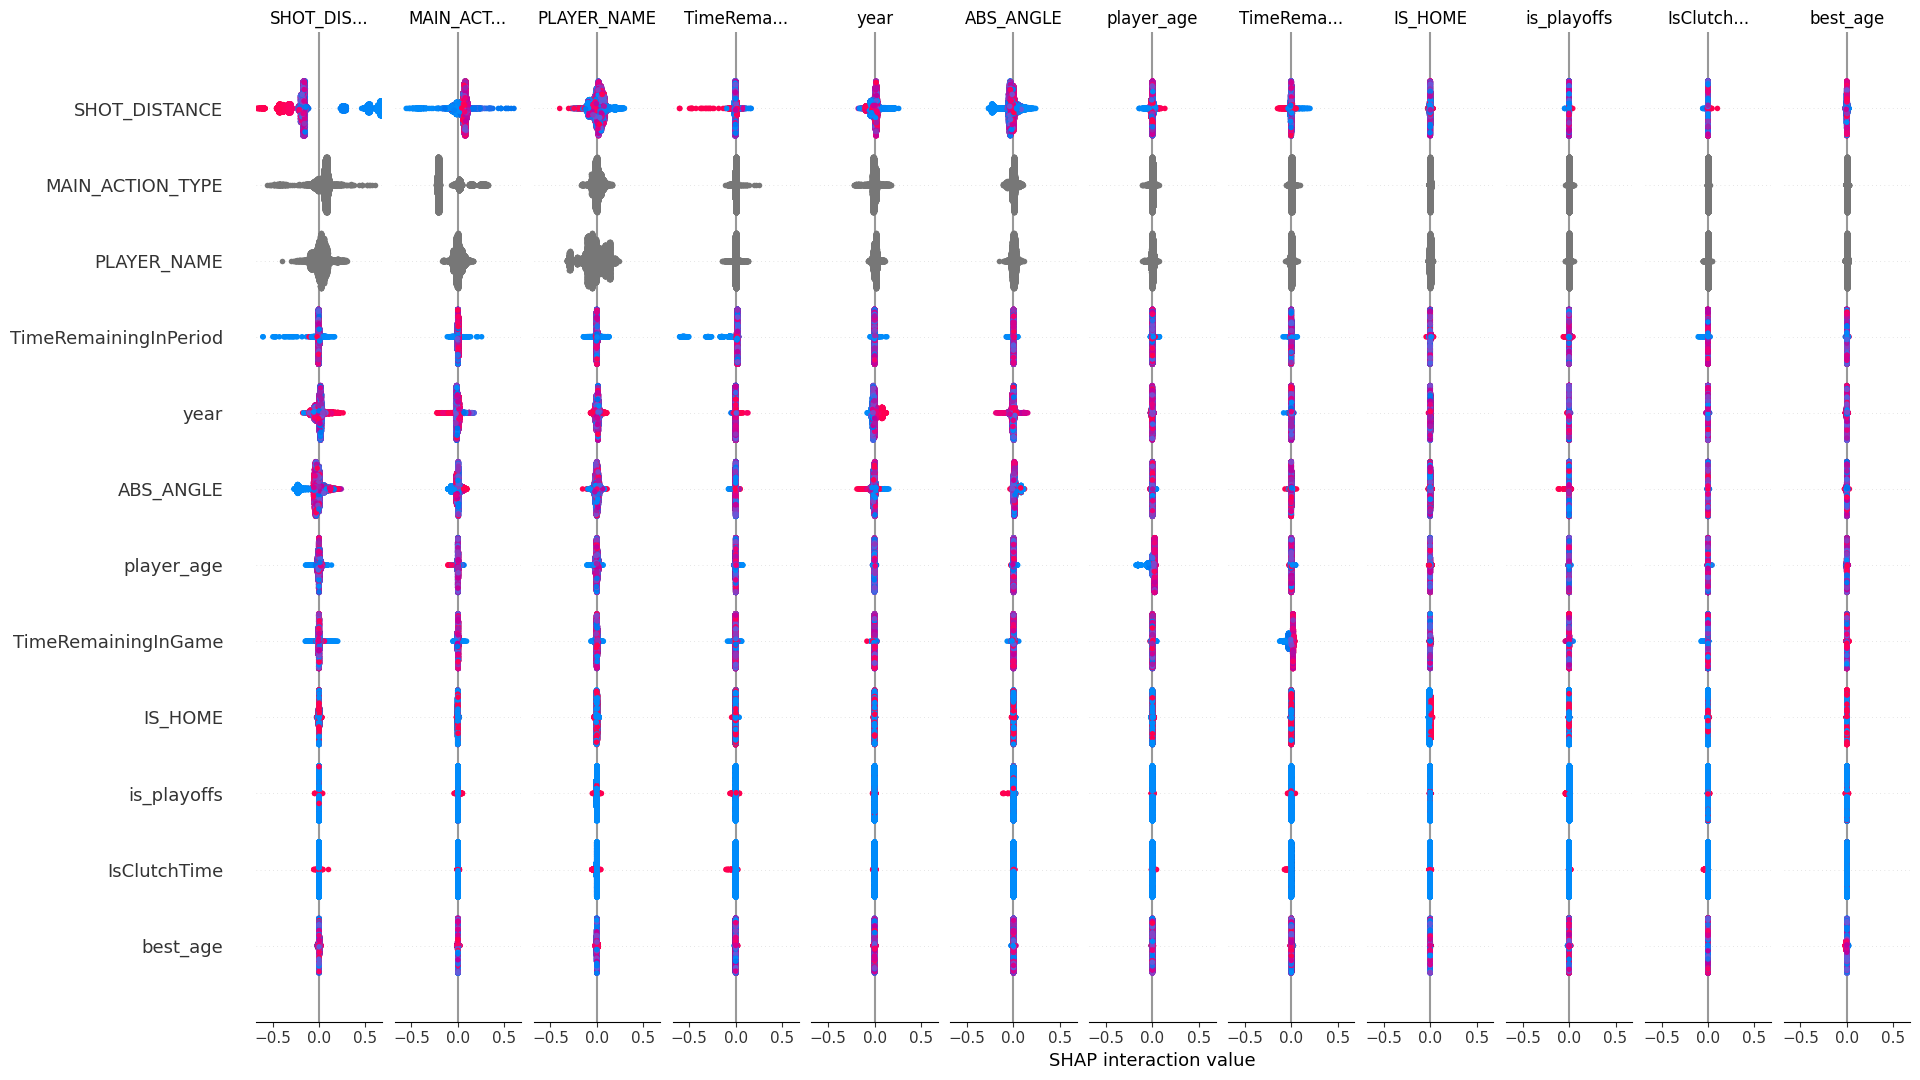

In [24]:
plt.figure(figsize=(35,35))
#shap_plotter.plot_interaction_summary()
sample = shap_plotter.X_test.sample(10000, random_state=42)

sample_renamed = sample.copy()

sample_renamed.columns = [
    c.replace("cat__", "").replace("MAIN_ACTION_TYPE_", "").replace("SHOT_TYPE_", "").replace("num__", "").replace("pass__", "")
    for c in sample.columns
]
sample_shap = sample_renamed.copy()
cat_mappings = {}
for col in sample_shap.select_dtypes(['category']).columns:
    cat_type = sample_shap[col].astype("category").cat.categories
    sample_shap[col] = sample_shap[col].astype("category").cat.codes
    cat_mappings[col] = dict(enumerate(cat_type))

    
interaction_values = shap_plotter.explainer.shap_interaction_values(sample_shap)
shap.summary_plot(
    interaction_values,
    sample_renamed,
    max_display=15,
    plot_size=(350, 350)
)



In [25]:
import numpy as np
import pandas as pd
#interaction_values = shap_plotter.explainer.shap_interaction_values(sample_shap)
interaction_strength = np.abs(interaction_values).mean(axis=0)
# 
interaction_df = pd.DataFrame(
    interaction_strength,
    columns=sample_shap.columns,
    index=sample_shap.columns
)



In [26]:
pairs = []
# Calculating most important interacting column pairs
for i in range(len(sample_shap.columns)):
    for j in range(i+1, len(sample_shap.columns)):

        strength = np.abs(
            interaction_values[:, i, j]
        ).mean()

        pairs.append((
            sample_shap.columns[i],
            sample_shap.columns[j],
            strength
        ))

pairs = sorted(
    pairs,
    key=lambda x: x[2],
    reverse=True
)

# pairs[:10]

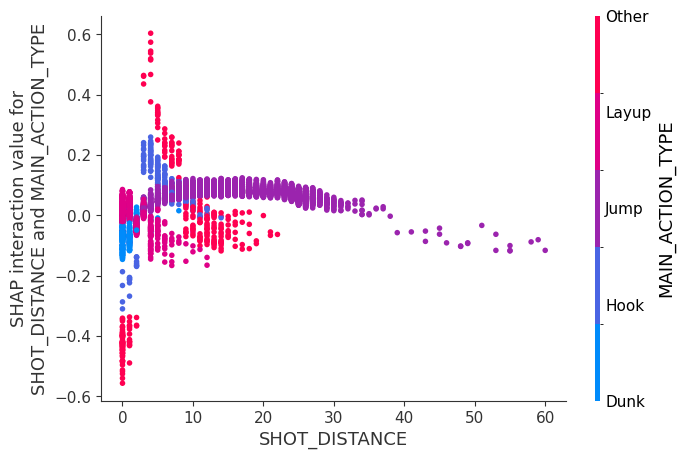

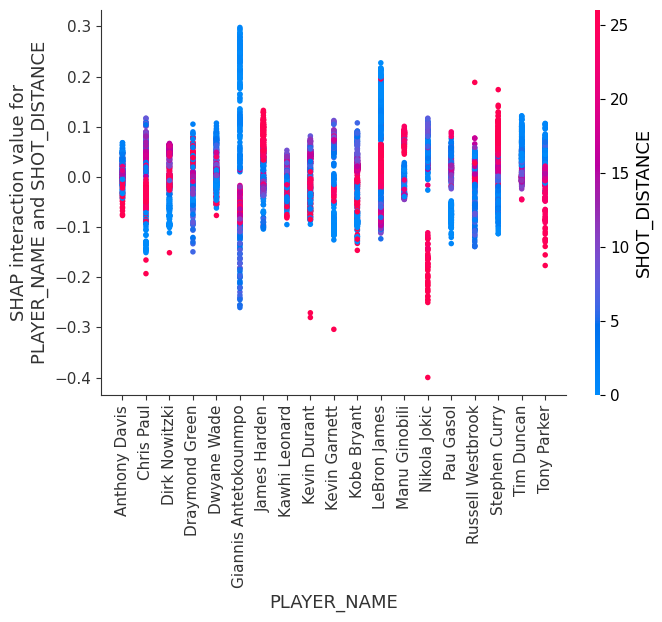

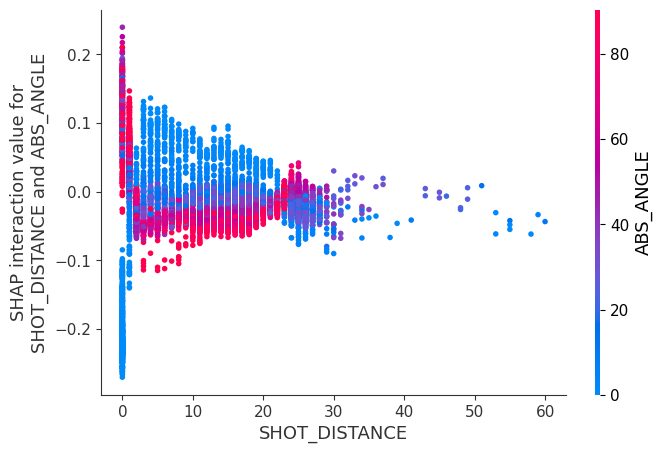

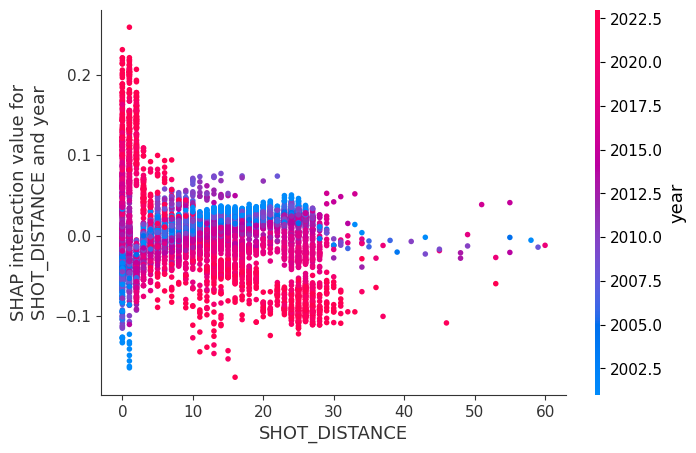

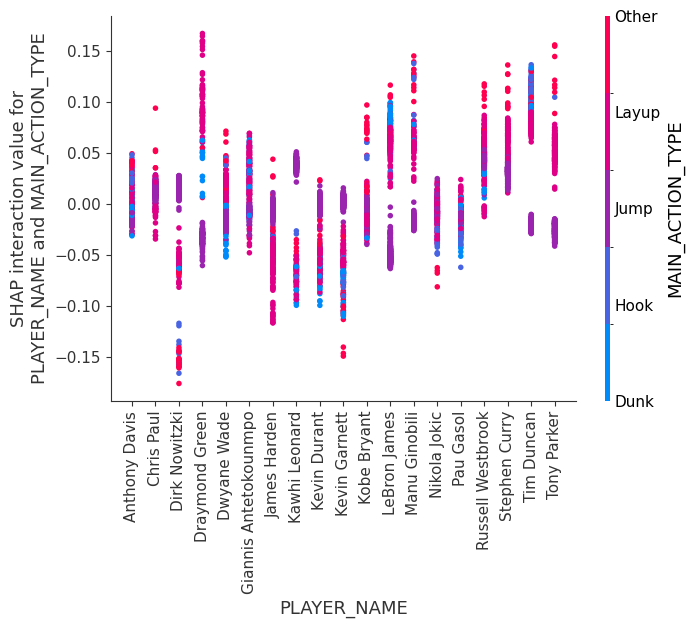

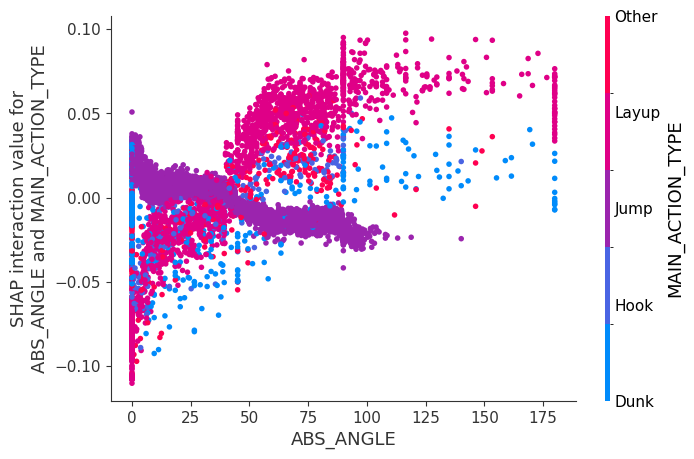

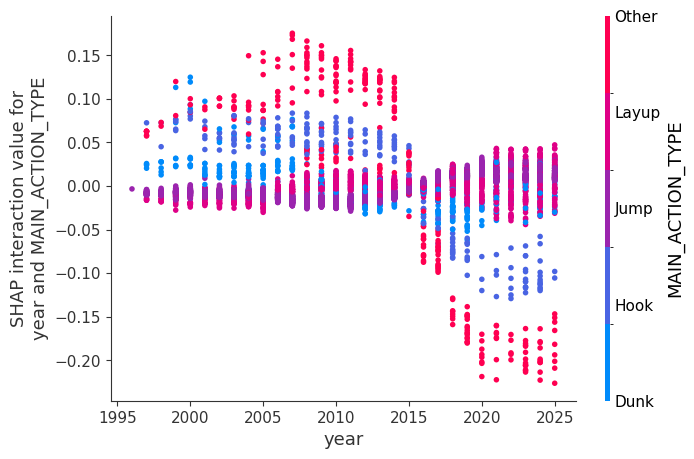

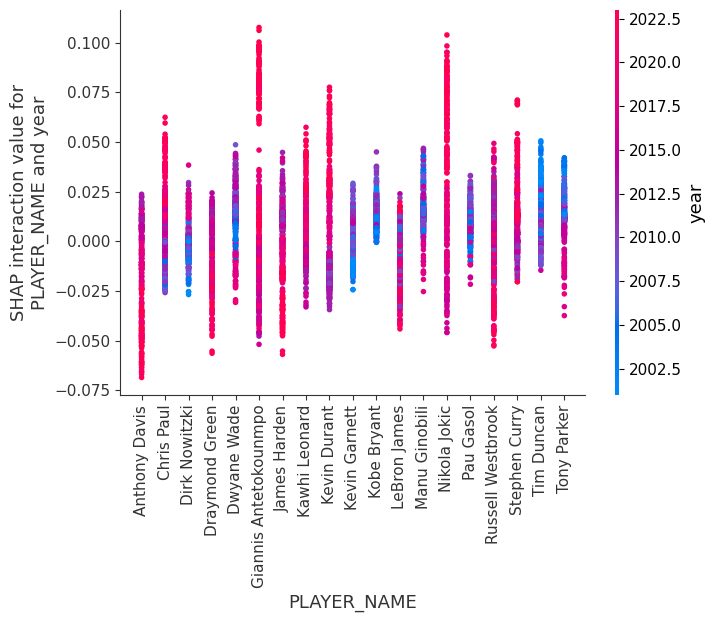

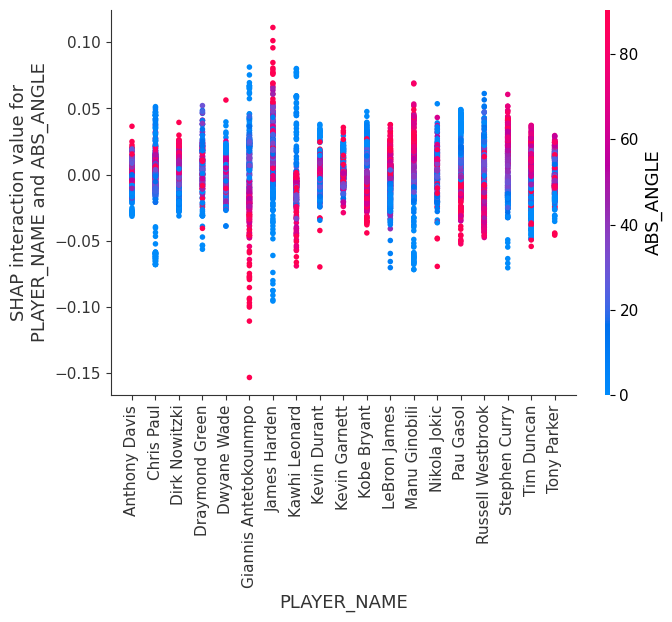

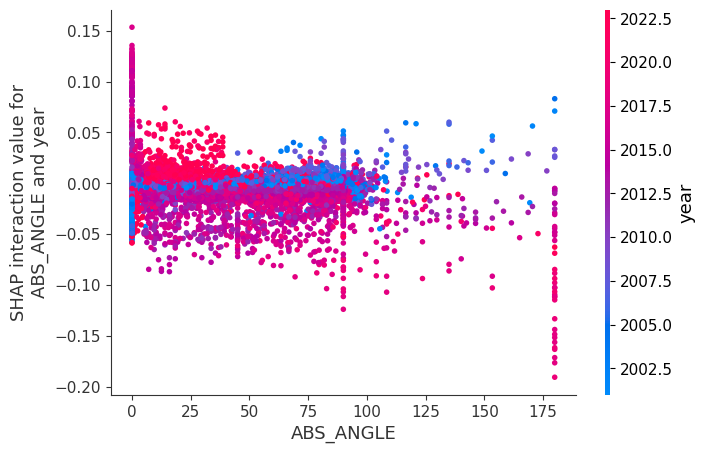

In [27]:
# dependence plot for most important features interactions

for pair in pairs[:10]:
    if pair[1] == 'PLAYER_NAME':
        # player name better on x-axis than on cbar legend
        pair = pair[1], pair[0]
    shap.dependence_plot(
        (pair[0],pair[1]),
        interaction_values,
        sample_shap,show=False
    )
    if pair[0] in list(cat_mappings.keys()):
        ax = plt.gca()
        
        mapping = cat_mappings[pair[0]]
        
        ax.set_xticks(list(mapping.keys()))
        ax.set_xticklabels(list(mapping.values()), rotation=90)
        
    if pair[1] in list(cat_mappings.keys()):
        fig = plt.gcf()
        
        ax = plt.gca()
        
        # letzte Achse ist meistens die colorbar
        cbar_ax = fig.axes[-1]
        
        mapping = cat_mappings[pair[1]]
        
        cbar_ax.set_yticks(list(mapping.keys()))
        cbar_ax.set_yticklabels(list(mapping.values()))
    plt.show()
    
    
    

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


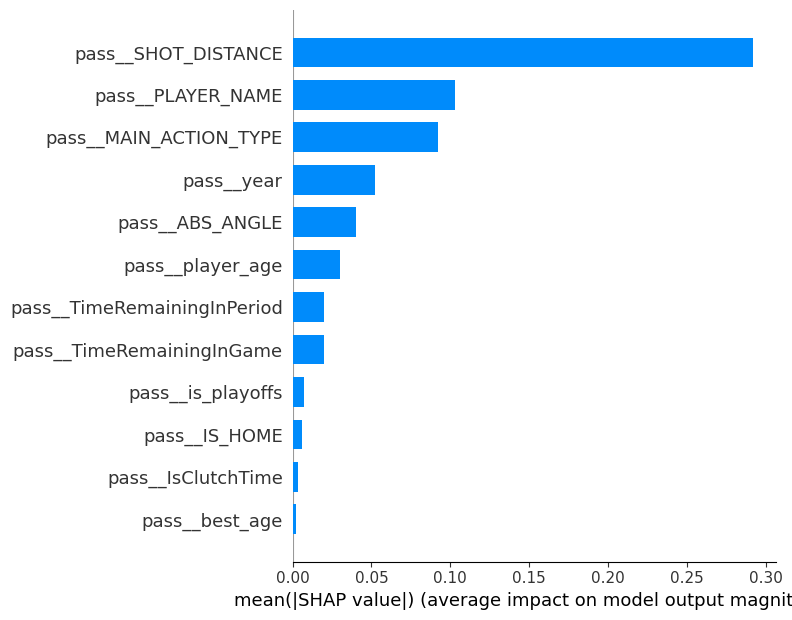

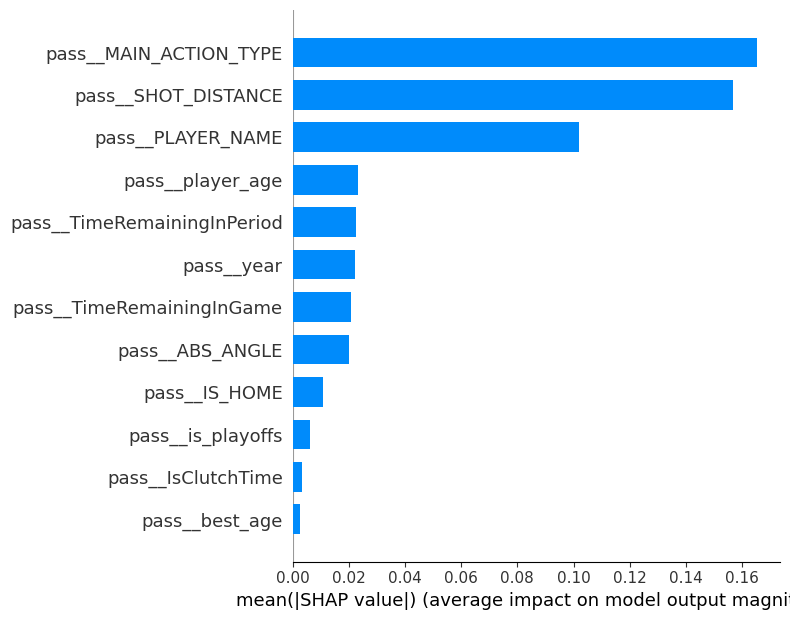

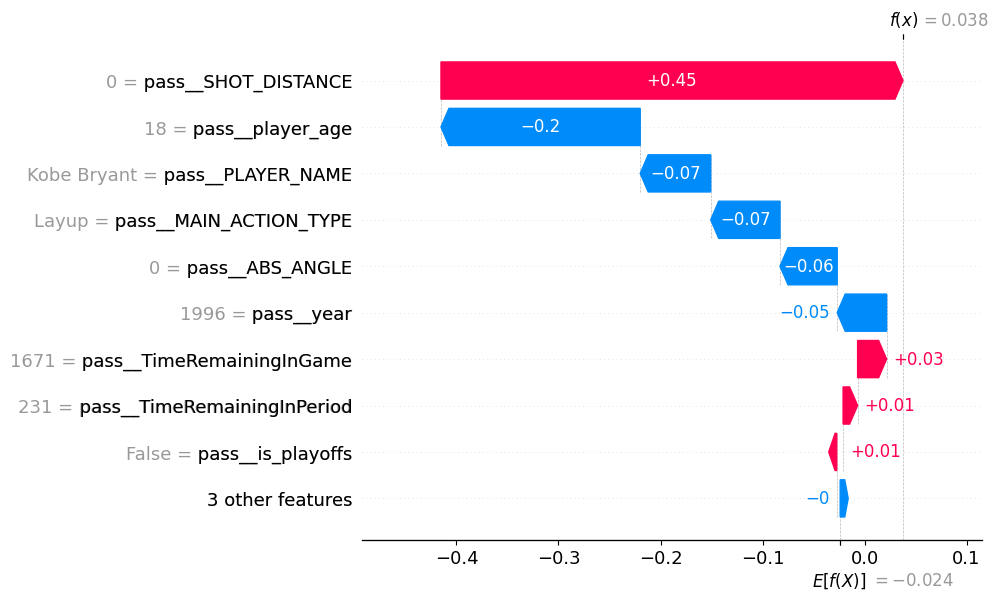

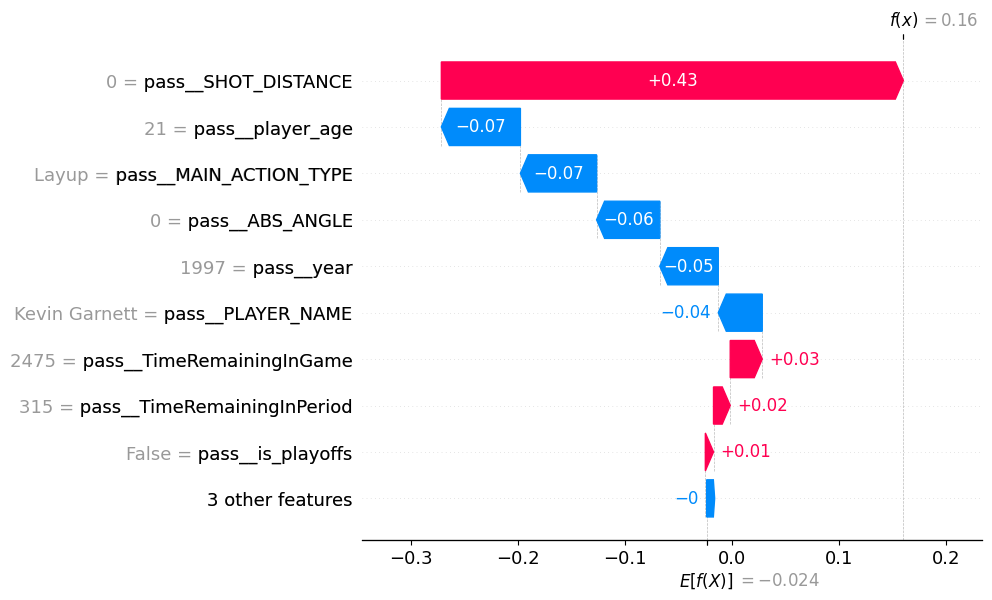

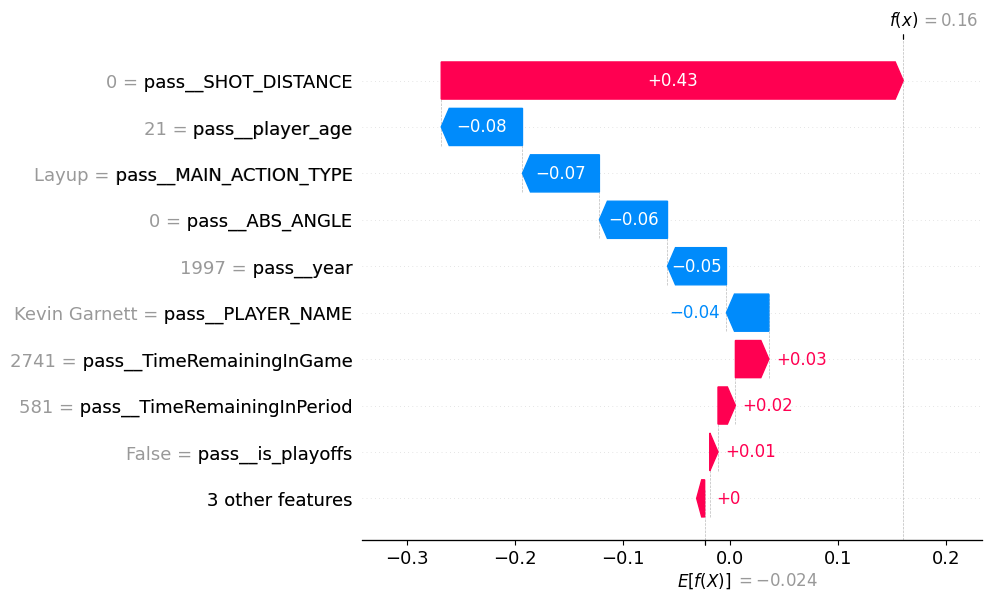

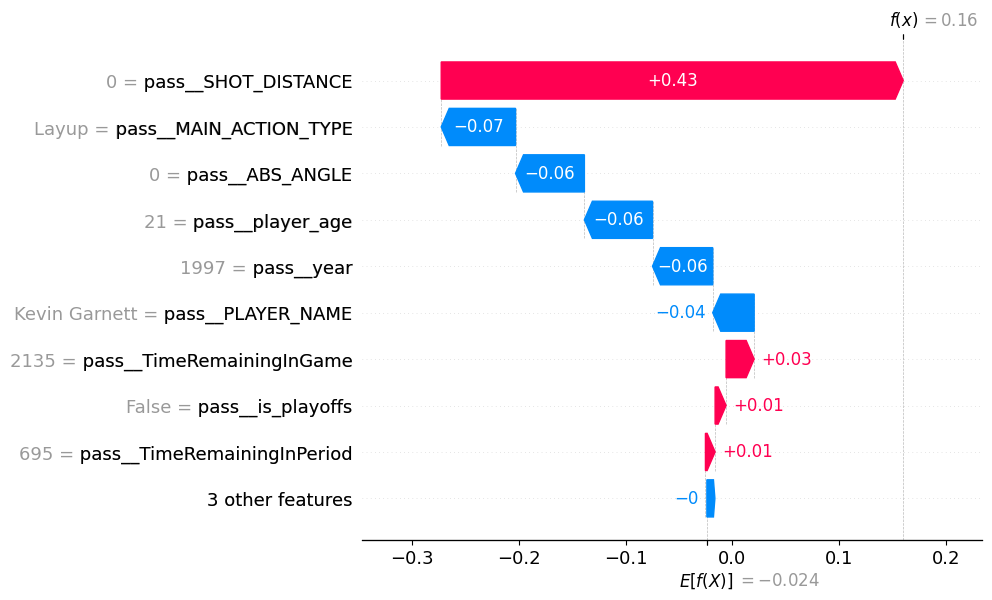

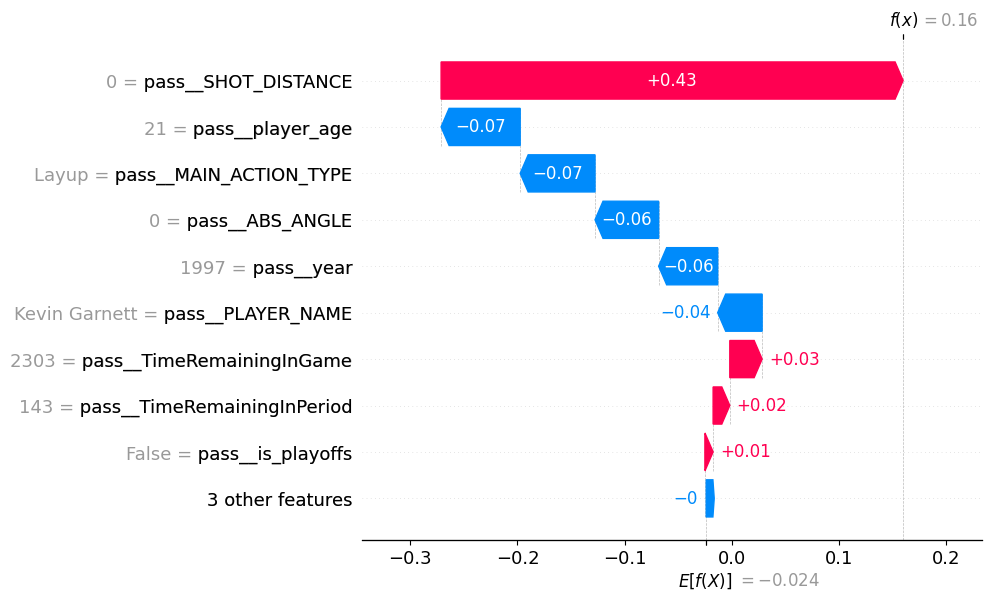

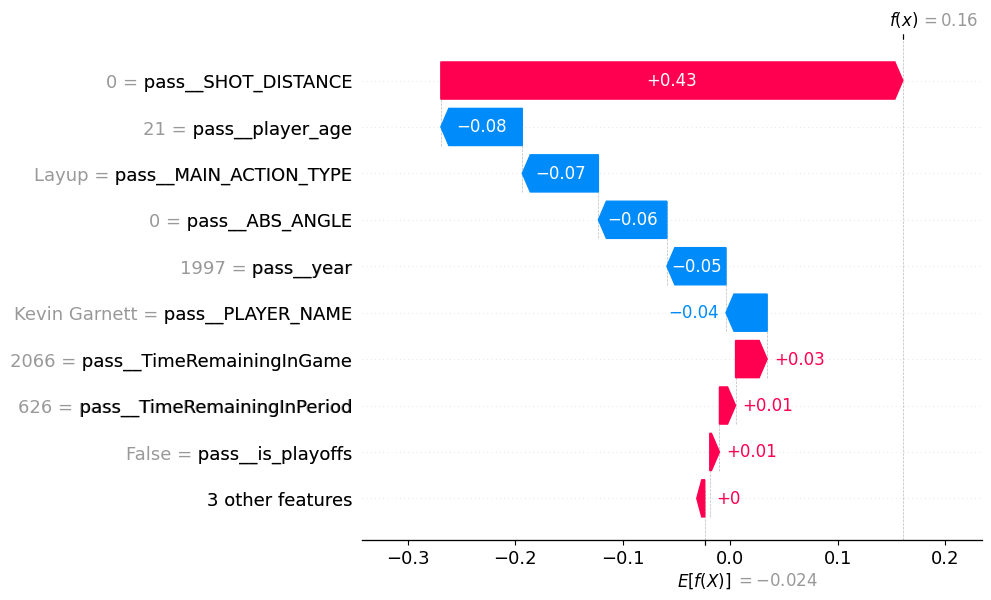

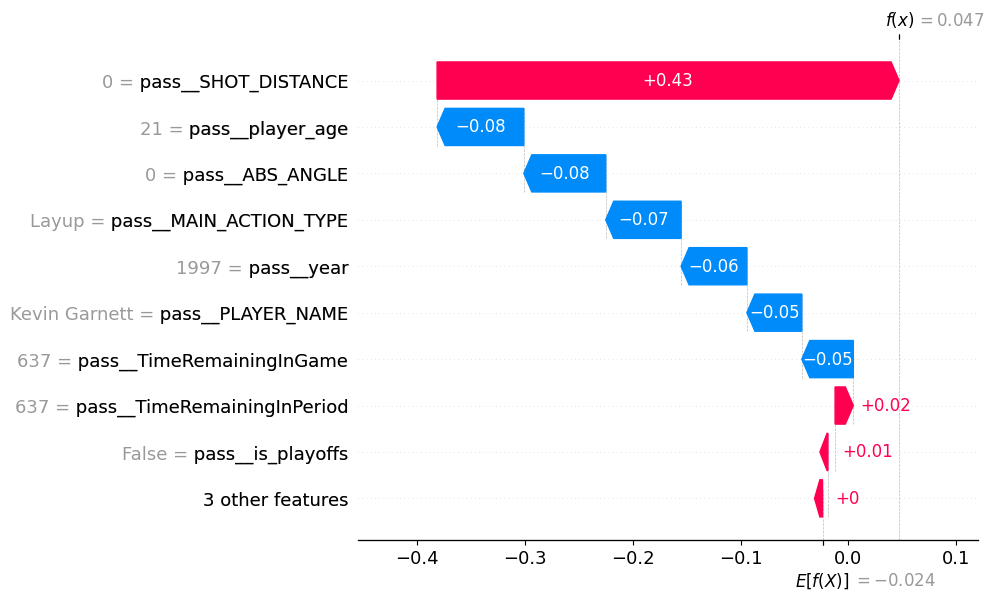

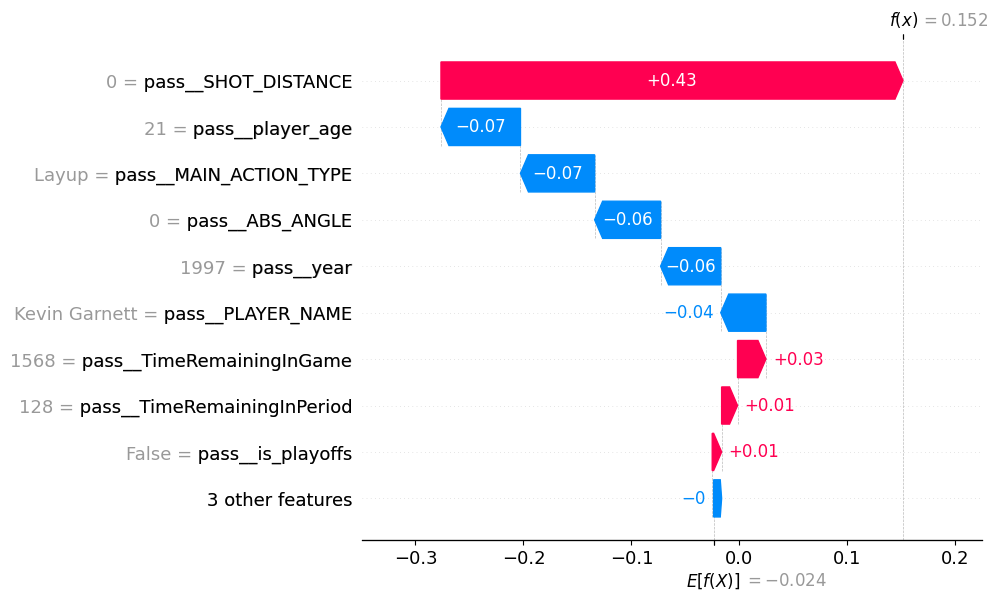

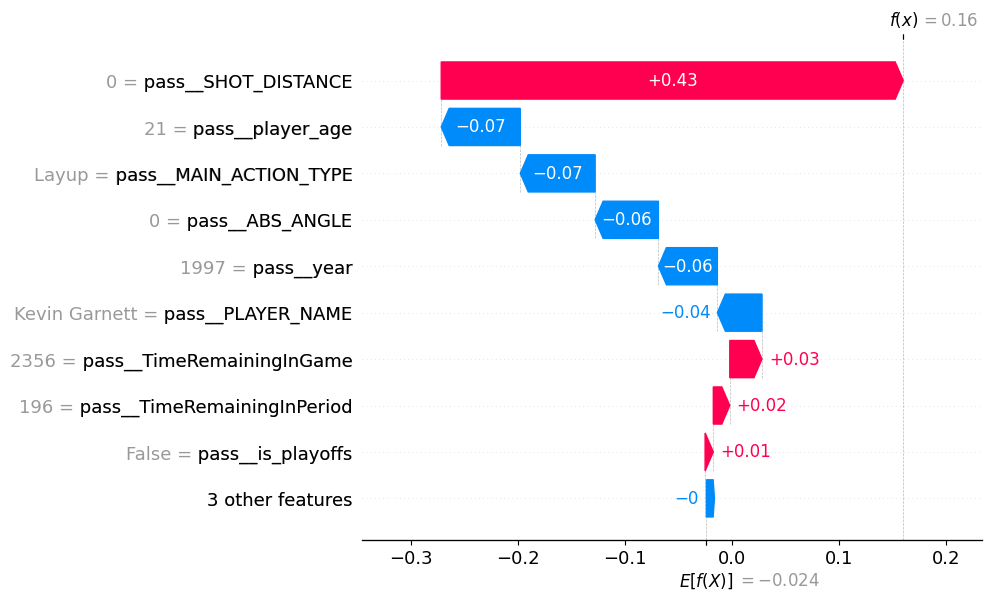

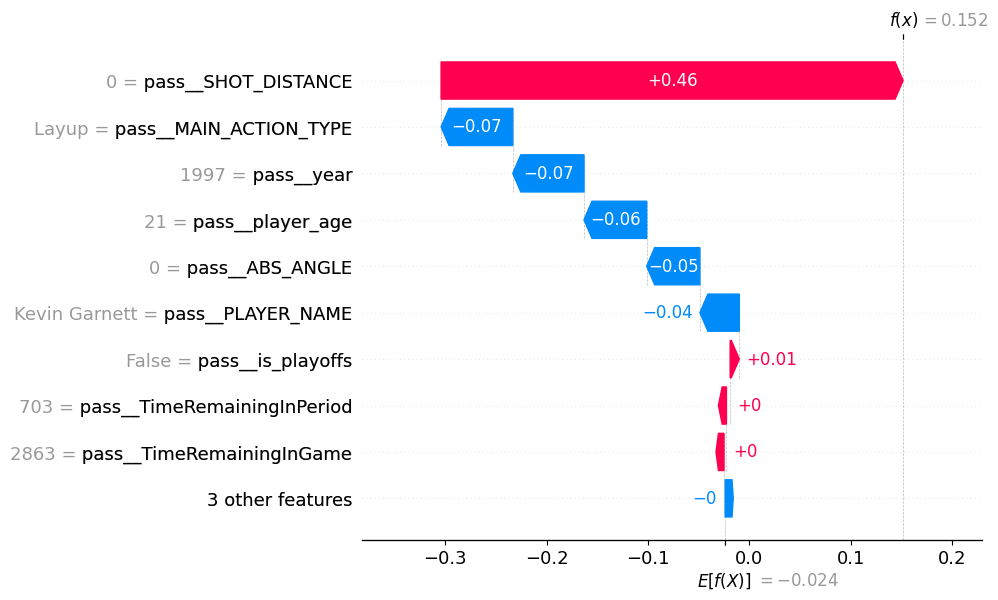

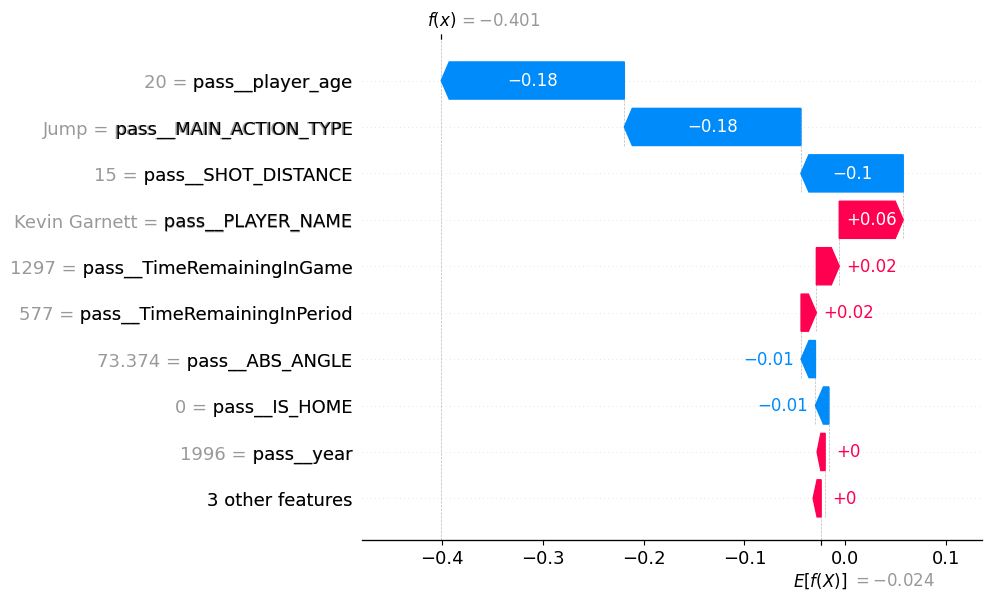

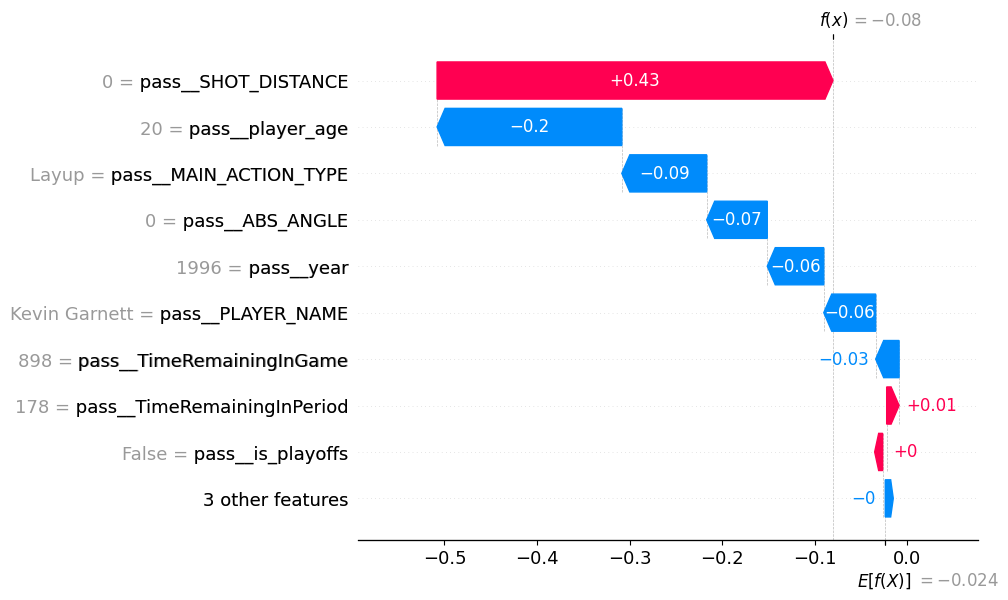

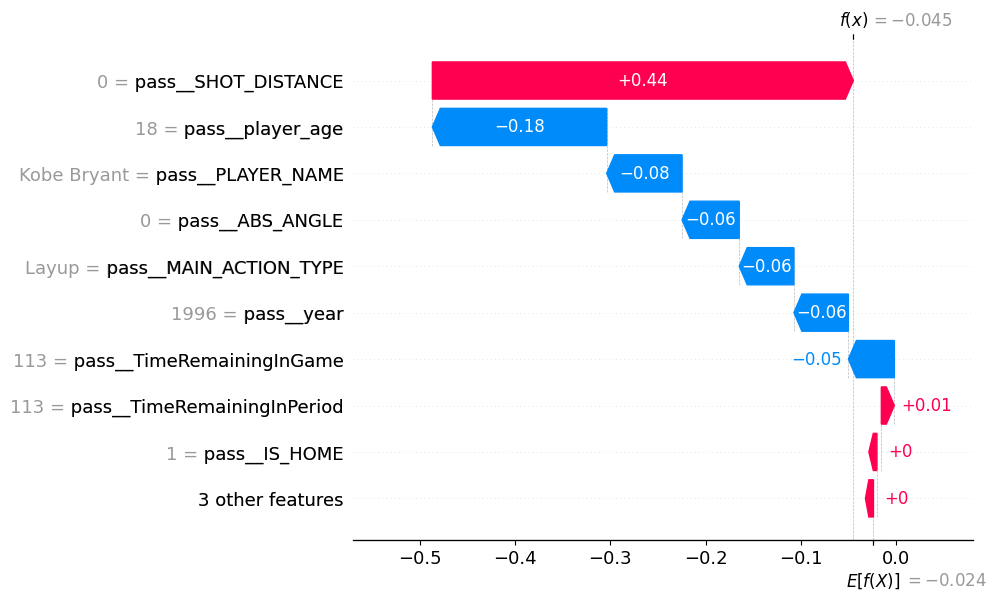

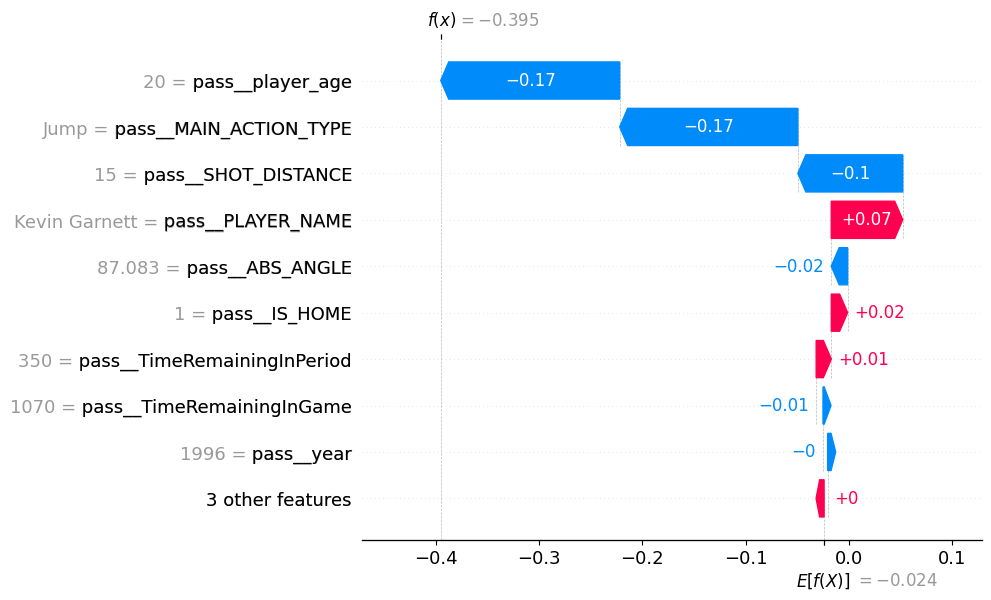

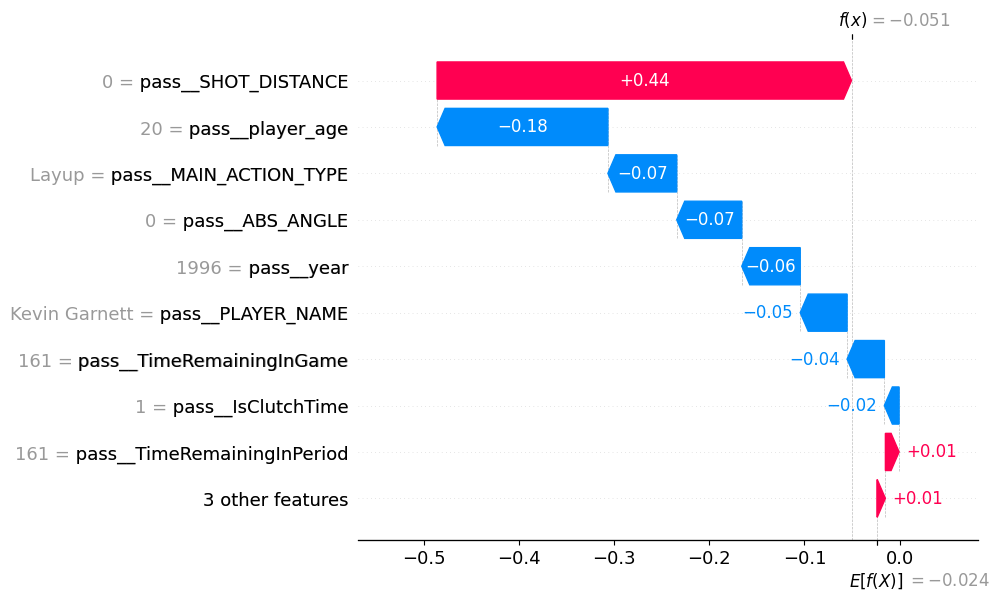

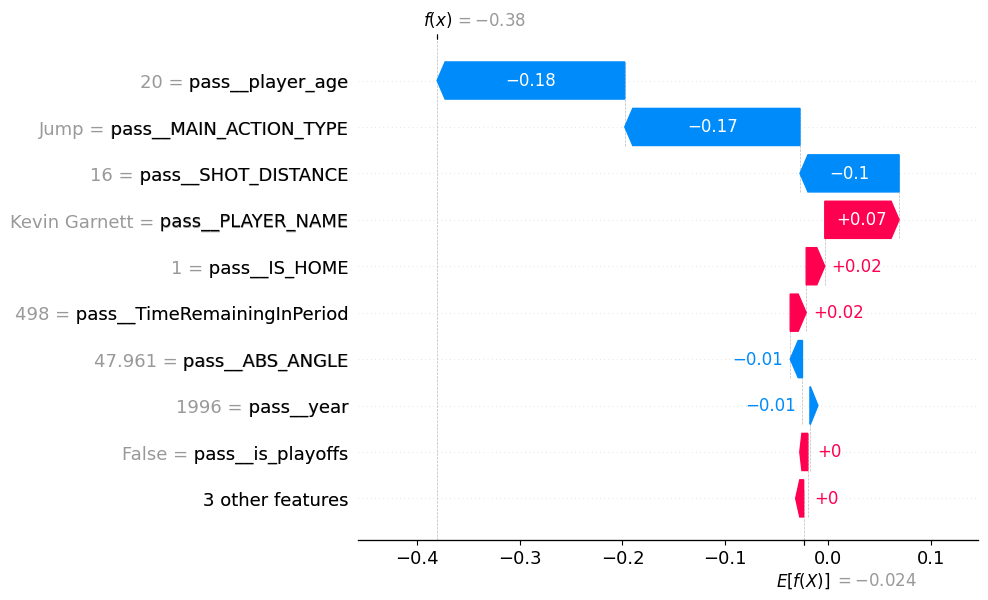

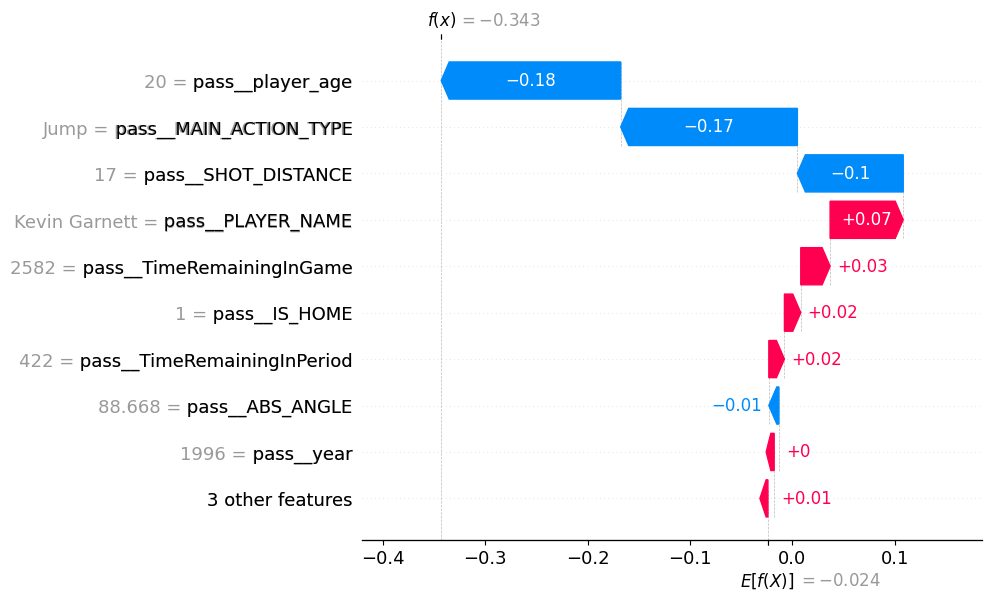

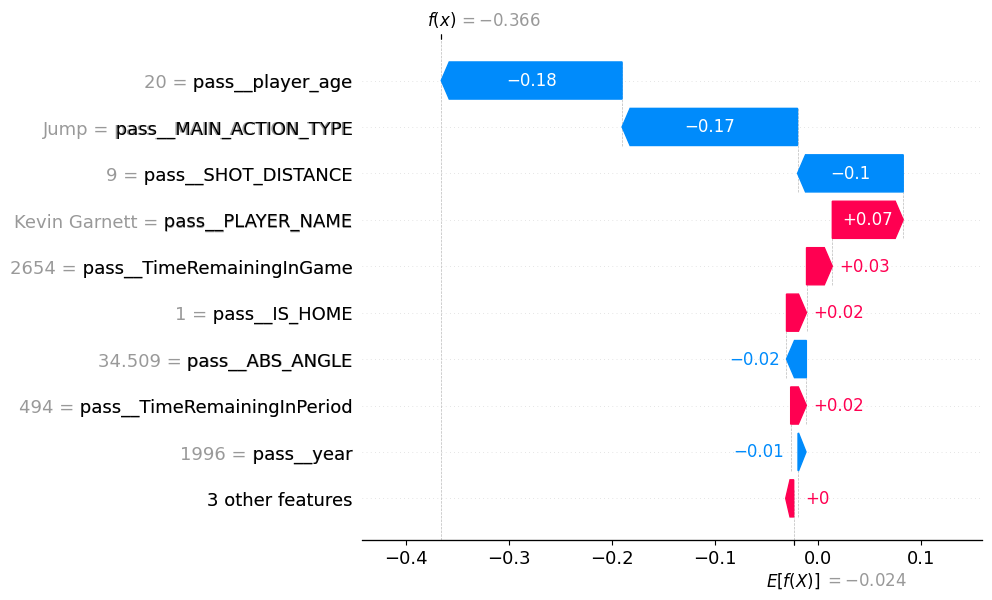

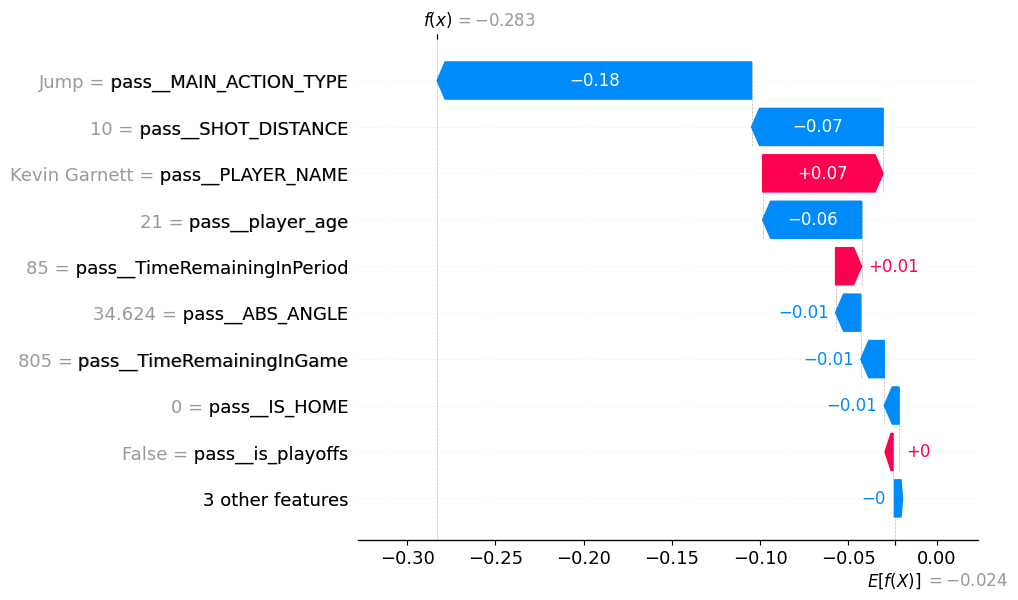

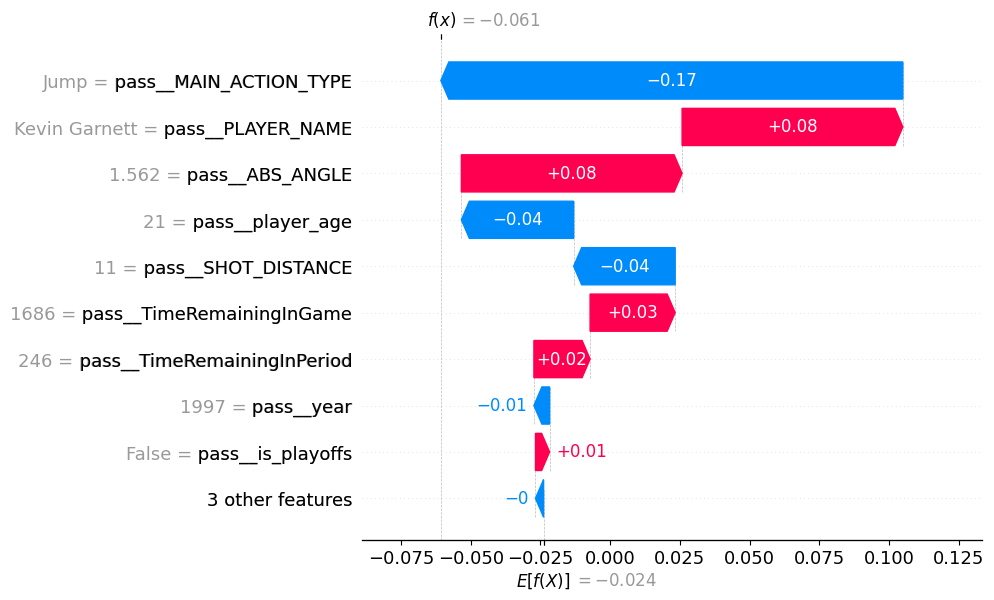

In [31]:
y_proba = model.predict_proba(X_test)
y_pred = y_proba[:,1] > 0.5

fp_decision_border = X_test[(y_pred > y_test) & (y_proba[:,1] < 0.6)]
fn_decision_border = X_test[(y_pred < y_test) & (y_proba[:,1] > 0.4)]
shap_plotter_fp = create_shap_plotter_from_model_and_data(model, fp_decision_border, X_train)
shap_plotter_fn = create_shap_plotter_from_model_and_data(model, fn_decision_border, X_train)

shap_plotter_fp.plot_summary()
shap_plotter_fn.plot_summary()

for i in range(10):
    shap_plotter_fp.plot_waterfall(i)



plt.show()

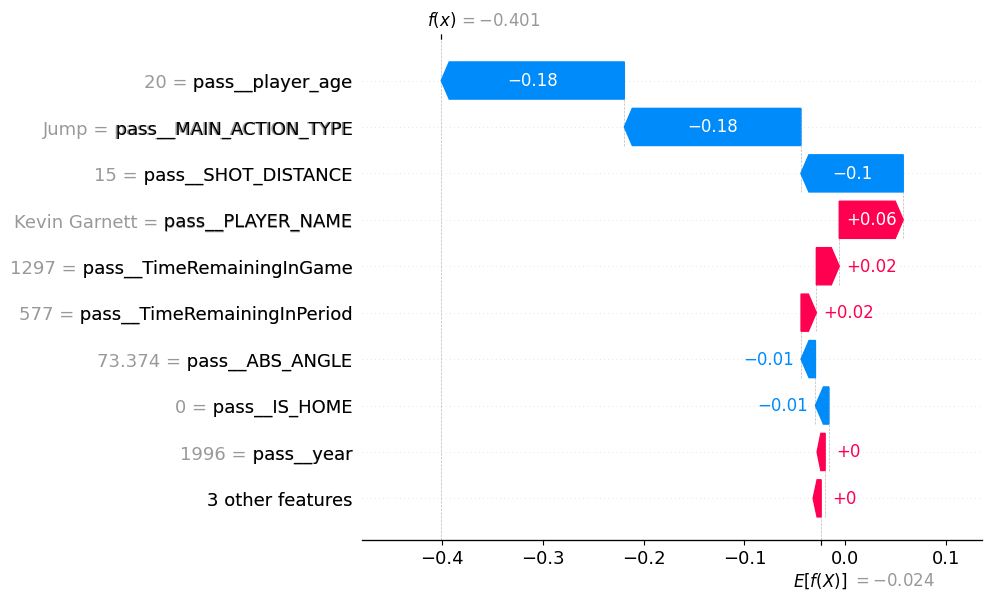

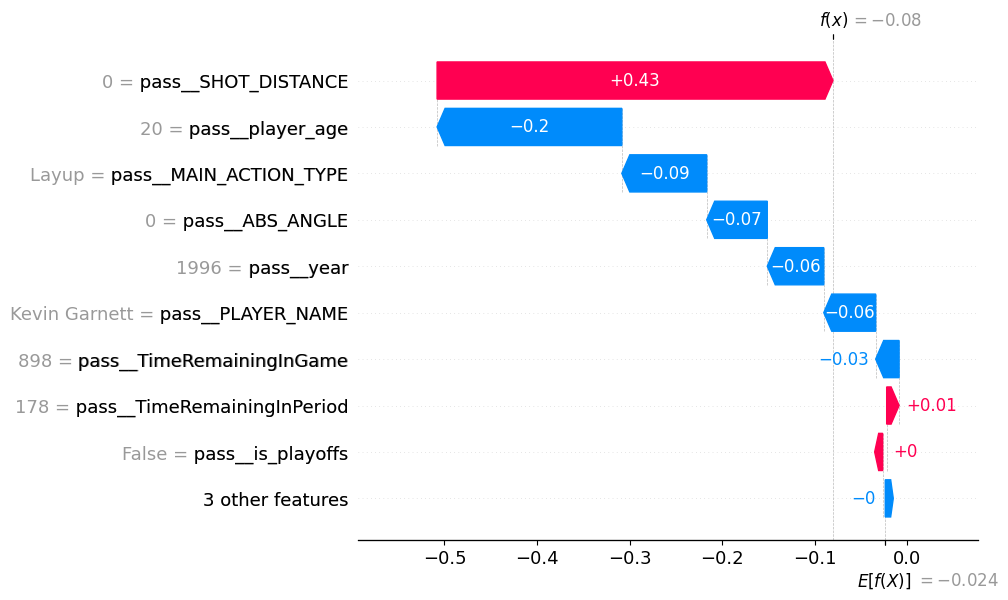

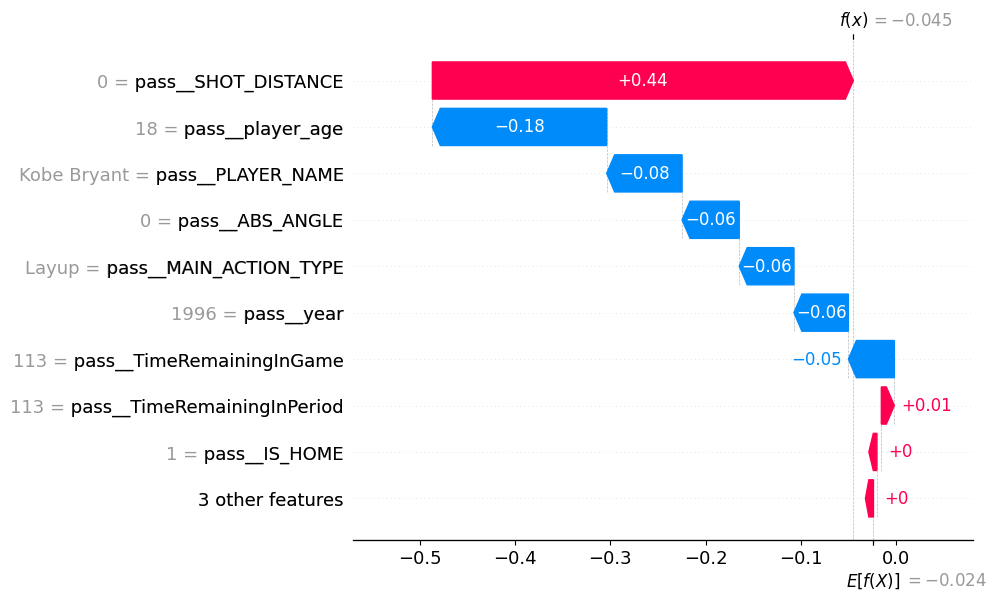

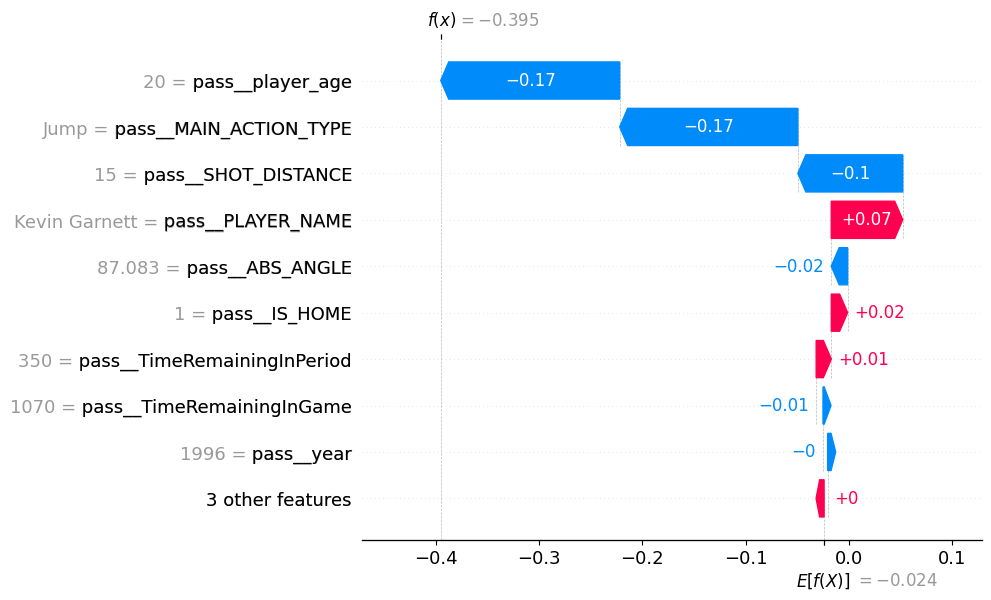

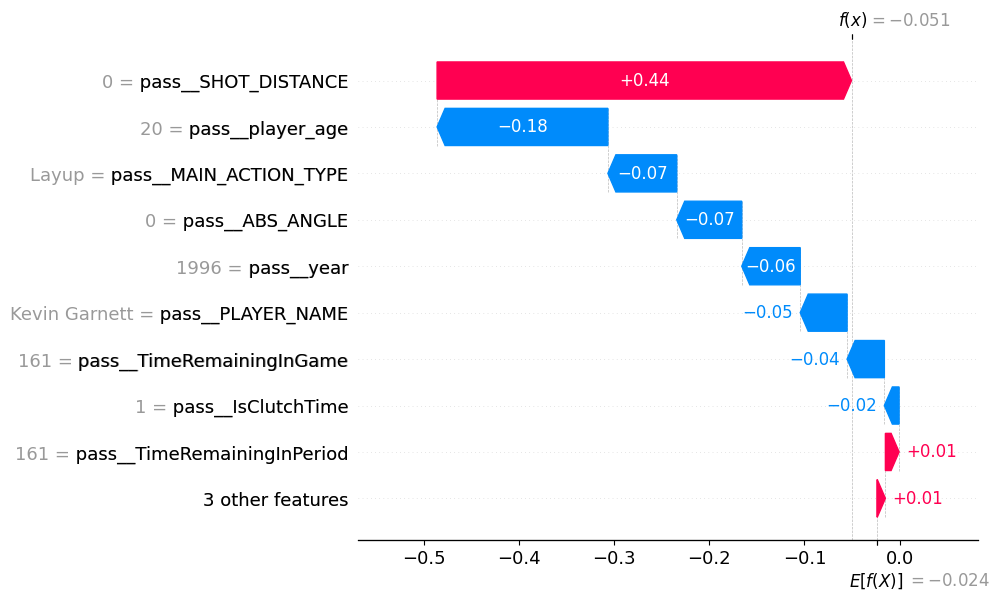

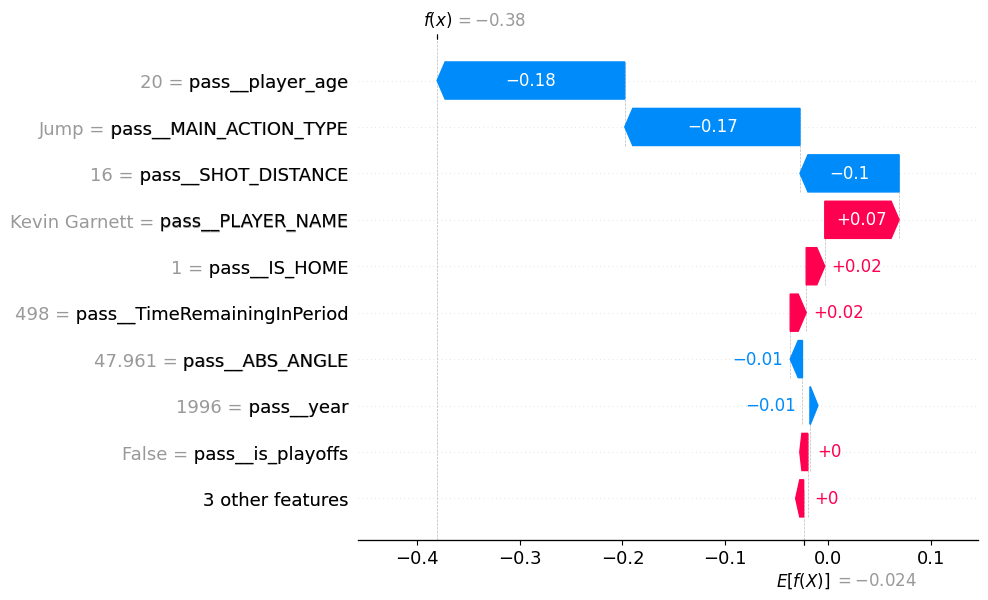

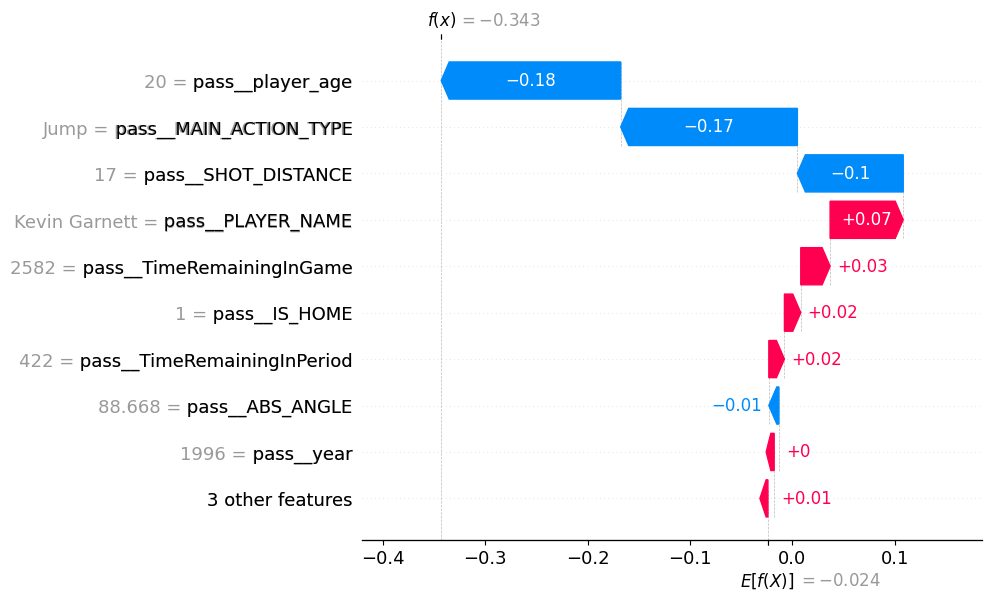

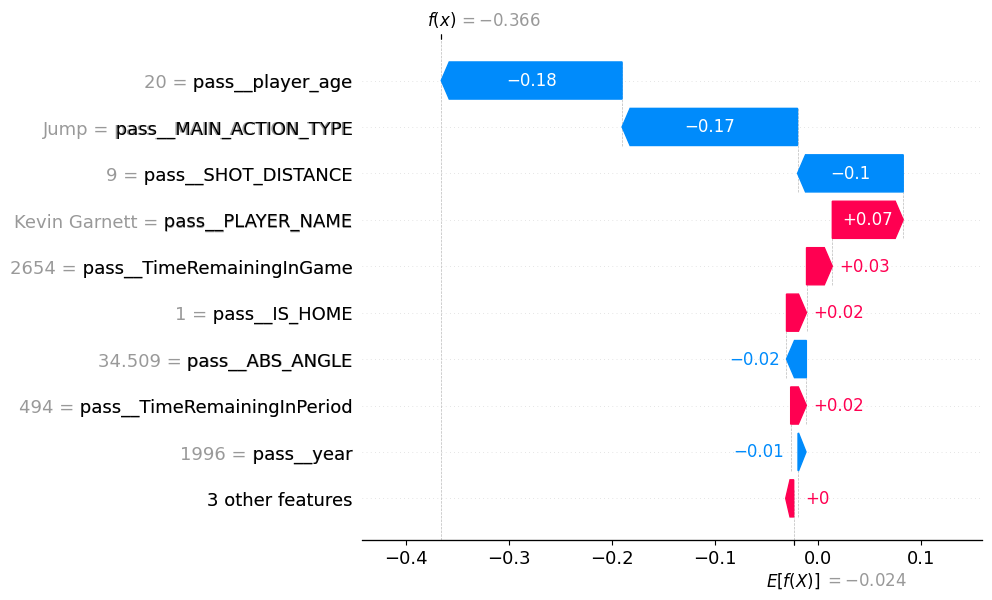

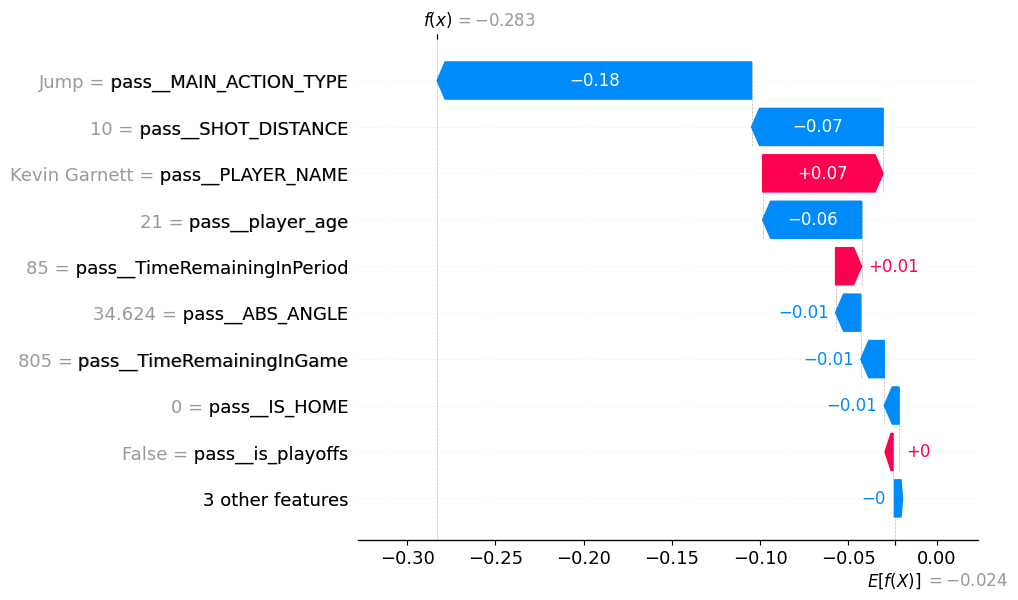

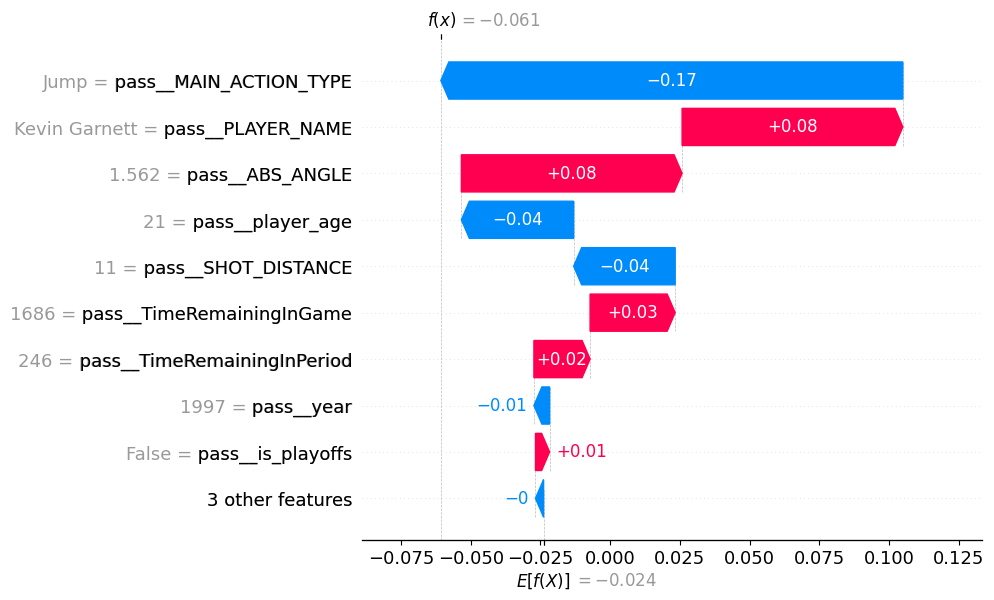

In [36]:

for i in range(10):
    shap_plotter_fn.plot_waterfall(i)
plt.show()